# 01 · Statistics Basics: Data, Variables and First Charts

This is the first notebook of my statistics experiments. Before calculating anything, we need a few basic ideas: what statistics is, what a sample is, what kinds of variables exist, and how to draw the first simple charts.

**What you will learn here**

1. What statistics is and its two main types
2. Population vs sample
3. Four ways of taking a sample
4. Types of variables (quantitative, qualitative, discrete, continuous)
5. Measurement scales (nominal, ordinal, interval, ratio)
6. Frequency tables, bar charts, histograms and the density curve (PDF)

## The dataset: restaurant tips

| | |
|---|---|
| **Name** | Tips |
| **Source** | [seaborn-data on GitHub](https://github.com/mwaskom/seaborn-data/blob/master/tips.csv), originally from Bryant & Smith (1995), *Practical Data Analysis: Case Studies in Business Statistics* |
| **Licence** | Shared for teaching in the seaborn library, no formal licence stated |
| **Rows** | 244 restaurant bills, recorded by one waiter over a few months |

A copy is saved in `data/tips.csv`, so the notebook works without internet.

| Column | Meaning |
|---|---|
| `total_bill` | Total bill in US dollars (including tax) |
| `tip` | Tip given, in US dollars |
| `sex` | Sex of the person who paid |
| `smoker` | Was there a smoker at the table? (Yes / No) |
| `day` | Day of the week (Thur, Fri, Sat, Sun) |
| `time` | Lunch or Dinner |
| `size` | Number of people at the table |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

BLUE = "#2a78d6"
ORANGE = "#eb6834"
GREEN = "#1baf7a"

In [2]:
tips = pd.read_csv("../data/tips.csv")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
print("Rows and columns:", tips.shape)

Rows and columns: (244, 7)


---
## 1. What is statistics?

> **Theory**
>
> **Statistics** is the science of collecting, organising and analysing data, so we can make better decisions.

**Data** means facts or pieces of information that we can measure. For example, the bills in our table: 16.99, 10.34, 21.01 dollars and so on.

**Why do we need it?** The restaurant owner cannot look at 244 bills one by one and "feel" what is going on. Statistics turns a big pile of numbers into a few clear answers, like *"the average bill is about 20 dollars"*.

### Two types of statistics

| Type | What it does | Example question on our data |
|---|---|---|
| **Descriptive statistics** | Organises and summarises the data we already have | What is the average bill in this restaurant? |
| **Inferential statistics** | Uses the data we have (a sample) to draw conclusions about a bigger group | Do customers in *all* restaurants of this city tip about 15%? |

Descriptive tools: mean, median, histograms, box plots, bar charts.
Inferential tools: hypothesis tests, p-values, z-test, t-test, chi-square, ANOVA. We will meet all of them in the next notebooks.

In [4]:
# A descriptive answer: the average bill of these 244 tables
average_bill = tips["total_bill"].mean()
print("Average bill in this data:", round(average_bill, 2), "dollars")

Average bill in this data: 19.79 dollars


That is descriptive statistics: we described the data we have. If we now said *"so the average bill in every restaurant of the city is about 19.79 dollars"*, we would be making an inference, and we would need inferential statistics to check how much we can trust that claim.

---
## 2. Population and sample

> **Theory**
>
> - **Population (N)**: the whole group we care about. Example: every bill paid in this restaurant, ever.
> - **Sample (n)**: the part of the population we actually observed. Example: the 244 bills in our file.

Capital **N** is used for the population size and small **n** for the sample size.

**Why do we need samples?** Collecting the full population is usually too expensive or impossible. In an election exit poll, reporters cannot ask every voter, so they ask a sample of people from different areas and use them to estimate the result.

**A small experiment.** Let's pretend our 244 bills are the full population. We take a sample of 10 bills and see how close the sample average is to the population average.

In [5]:
np.random.seed(42)

population_mean = tips["total_bill"].mean()
sample = tips["total_bill"].sample(n=10)

print("Population mean (N = 244):", round(population_mean, 2))
print("Sample mean     (n = 10): ", round(sample.mean(), 2))

Population mean (N = 244): 19.79
Sample mean     (n = 10):  18.1


In [6]:
# Repeat it with bigger samples
for n in [10, 50, 150]:
    sample_mean = tips["total_bill"].sample(n=n, random_state=1).mean()
    print(f"n = {n:3d}  ->  sample mean = {sample_mean:.2f}")

print(f"Population mean = {population_mean:.2f}")

n =  10  ->  sample mean = 16.28
n =  50  ->  sample mean = 20.73
n = 150  ->  sample mean = 19.88
Population mean = 19.79


> **Key idea:** a sample mean is close to the population mean but not exactly equal. Bigger samples usually land closer. The whole field of inferential statistics is about measuring *how close* we can expect to be.

---
## 3. Sampling techniques

How we choose the sample matters a lot. A bad sample gives a wrong picture, no matter how good the maths is afterwards.

| Technique | How it works | Real example |
|---|---|---|
| **Simple random sampling** | Every member of the population has the same chance of being picked | Exit polls, lucky draws |
| **Stratified sampling** | Split the population into non-overlapping groups (strata), then sample from each group | Survey that must include men and women in the right proportions |
| **Systematic sampling** | Pick every k-th member | Stand outside a mall and ask every 7th person |
| **Convenience sampling** | Only people who are easy to reach or want to take part | An online survey that only interested people fill in |

Which one to use depends on the problem. For a medicine trial you would not use convenience sampling, you would pick people based on who the medicine is for.

**Code.** Let's try all four on the tips data. We will take 20 bills each time and look at how many dinner bills end up in the sample.

In [7]:
dinner_share_population = (tips["time"] == "Dinner").mean()
print("Share of dinner bills in the population:", round(dinner_share_population, 2))

Share of dinner bills in the population: 0.72


In [8]:
# 1. Simple random sampling
random_sample = tips.sample(n=20, random_state=7)

# 2. Stratified sampling: keep the lunch/dinner proportions
stratified_sample = tips.groupby("time").sample(frac=20 / len(tips), random_state=7)

# 3. Systematic sampling: every 12th bill (244 / 20 is about 12)
systematic_sample = tips.iloc[::12].head(20)

# 4. Convenience sampling: just take the first 20 rows of the file
convenience_sample = tips.head(20)

samples = {
    "Simple random": random_sample,
    "Stratified": stratified_sample,
    "Systematic": systematic_sample,
    "Convenience": convenience_sample,
}

for name, s in samples.items():
    share = (s["time"] == "Dinner").mean()
    print(f"{name:14s} n = {len(s):2d}   share of dinner = {share:.2f}")

Simple random  n = 20   share of dinner = 0.60
Stratified     n = 20   share of dinner = 0.70
Systematic     n = 20   share of dinner = 0.70
Convenience    n = 20   share of dinner = 1.00


**What happened?**

- The stratified sample keeps the dinner share close to the population share, because we forced it to.
- The convenience sample (first 20 rows) is **100% dinner**. The first rows in the file are all Sunday dinners, so this "easy" sample is badly biased. If we used it to study lunch tips, we would have no lunch data at all.

> **Key idea:** the easiest sample is often the most biased one.

Read more: [Sampling bias (Wikipedia)](https://en.wikipedia.org/wiki/Sampling_bias)

---
## 4. Variables

> **Theory**
>
> A **variable** is a property that can take different values. Height, bill amount, day of the week are all variables.

Two big families:

| Type | Meaning | In our data |
|---|---|---|
| **Quantitative** (numerical) | Measured with numbers, you can add, subtract, average them | `total_bill`, `tip`, `size` |
| **Qualitative** (categorical) | Describes a group or category | `sex`, `smoker`, `day`, `time` |

Quantitative variables split again:

| Type | Meaning | Example |
|---|---|---|
| **Discrete** | Whole numbers only, you count them | `size` (you can't have 2.5 people at a table), number of bank accounts |
| **Continuous** | Any value in a range, you measure them | `total_bill` = 16.99, height = 172.5 cm, rainfall = 1.25 cm |

In [9]:
tips.dtypes

total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64
dtype: object

In [10]:
for column in tips.columns:
    print(f"{column:11s} {tips[column].nunique():4d} unique values, e.g. {tips[column].unique()[:4]}")

total_bill   229 unique values, e.g. [16.99 10.34 21.01 23.68]
tip          123 unique values, e.g. [1.01 1.66 3.5  3.31]
sex            2 unique values, e.g. ['Female' 'Male']
smoker         2 unique values, e.g. ['No' 'Yes']
day            4 unique values, e.g. ['Sun' 'Sat' 'Thur' 'Fri']
time           2 unique values, e.g. ['Dinner' 'Lunch']
size           6 unique values, e.g. [2 3 4 1]


**Reading the output:** `size` has only 6 unique values (1 to 6 people) so it is discrete. `total_bill` has more than 200 different values with decimals, so it is continuous. `day` has 4 text labels, so it is categorical.

> **Note:** A number is not always quantitative. A pin code like 75013 is stored as a number, but taking the average of pin codes makes no sense. It is really a category.

**Quick quiz** (answers below)

| Variable | Type? |
|---|---|
| Marital status | ? |
| Length of a river | ? |
| Number of employees in a company | ? |
| Duration of a movie | ? |

<details><summary>Answers</summary>

Marital status: categorical. River length: continuous. Number of employees: discrete. Movie duration: continuous.
</details>

---
## 5. Measurement scales

There are four scales. They tell us which calculations make sense for a variable.

| Scale | Order matters? | Differences matter? | True zero? | Example |
|---|---|---|---|---|
| **Nominal** | No | No | No | Colour, gender, `day` as a name, flower type |
| **Ordinal** | Yes | No | No | Ranking in a class (1st, 2nd, 3rd), T-shirt size S < M < L |
| **Interval** | Yes | Yes | No | Temperature in °C or °F (0 °C does not mean "no temperature") |
| **Ratio** | Yes | Yes | Yes | Height, weight, salary, `total_bill` (0 dollars really means nothing) |

**Why does this matter?** On ratio data we can say "this bill is *twice* that one". On interval data we cannot: 20 °C is not twice as hot as 10 °C. On ordinal data the gap between rank 1 and rank 2 may be tiny or huge, so averaging ranks can mislead.

---
## 6. Frequency distribution and bar chart

> **Theory.** A **frequency table** counts how often each value appears. The **cumulative frequency** keeps adding the counts, so the last number is always the total.

**Small example** (8 colours): Green, Red, Yellow, Green, Red, Yellow, Green, Red

**Manual calculation**

| Colour | Frequency | Cumulative frequency |
|---|---|---|
| Green | 3 | 3 |
| Red | 3 | 6 |
| Yellow | 2 | 8 |

In [11]:
colours = pd.Series(["Green", "Red", "Yellow", "Green", "Red", "Yellow", "Green", "Red"])

colour_table = colours.value_counts().sort_index().to_frame("frequency")
colour_table["cumulative"] = colour_table["frequency"].cumsum()
colour_table

,frequency,cumulative
Green,3,3
Red,3,6
Yellow,2,8


> **Check:** Same numbers as the manual table. Now the real data: how many bills on each day?

In [12]:
day_order = ["Thur", "Fri", "Sat", "Sun"]

day_table = tips["day"].value_counts().reindex(day_order).to_frame("frequency")
day_table["cumulative"] = day_table["frequency"].cumsum()
day_table["percent"] = (day_table["frequency"] / len(tips) * 100).round(1)
day_table

,frequency,cumulative,percent
day,,,
Thur,62,62,25.4
Fri,19,81,7.8
Sat,87,168,35.7
Sun,76,244,31.1


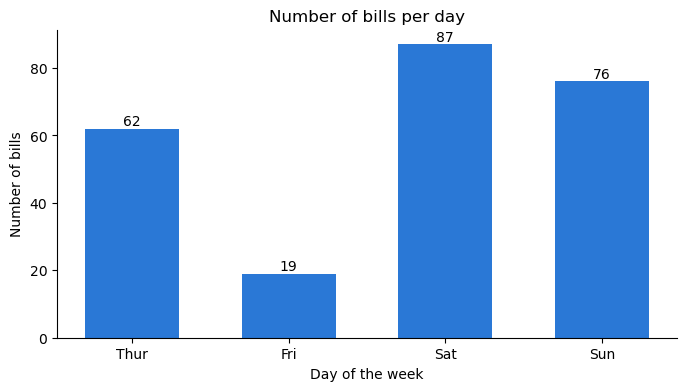

In [13]:
fig, ax = plt.subplots()
ax.bar(day_table.index, day_table["frequency"], color=BLUE, width=0.6)
for i, value in enumerate(day_table["frequency"]):
    ax.text(i, value + 1, str(value), ha="center")
ax.set_title("Number of bills per day")
ax.set_xlabel("Day of the week")
ax.set_ylabel("Number of bills")
plt.show()

The chart shows that Saturday and Sunday are the busiest days in this data, and Friday is very quiet (only 19 bills).

> **Bar chart vs histogram:** a bar chart is for **categories or discrete values** (days, colours). A histogram is for **continuous values** (bill amounts). The bars of a bar chart have gaps, the bars of a histogram touch each other because the number line is continuous.

---
## 7. Histogram

> **Theory.** A histogram splits a continuous variable into ranges called **bins** and counts how many values fall in each bin.

**Small example.** Ages = 10, 12, 14, 18, 24, 26, 30, 35, 36, 37, 40, 41, 42, 43, 50, 51 with bins of width 10.

**Manual calculation**

| Bin | Values in the bin | Count |
|---|---|---|
| 10 to 20 | 10, 12, 14, 18 | 4 |
| 20 to 30 | 24, 26 | 2 |
| 30 to 40 | 30, 35, 36, 37 | 4 |
| 40 to 50 | 40, 41, 42, 43 | 4 |
| 50 to 60 | 50, 51 | 2 |

(A value on the edge, like 30, goes into the bin that starts with it.)

In [14]:
ages = [10, 12, 14, 18, 24, 26, 30, 35, 36, 37, 40, 41, 42, 43, 50, 51]
bin_edges = [10, 20, 30, 40, 50, 60]

# docs: https://numpy.org/doc/stable/reference/generated/numpy.histogram.html
counts, edges = np.histogram(ages, bins=bin_edges)
for left, right, count in zip(edges[:-1], edges[1:], counts):
    print(f"{left} to {right}: {count}")

10 to 20: 4
20 to 30: 2
30 to 40: 4
40 to 50: 4
50 to 60: 2


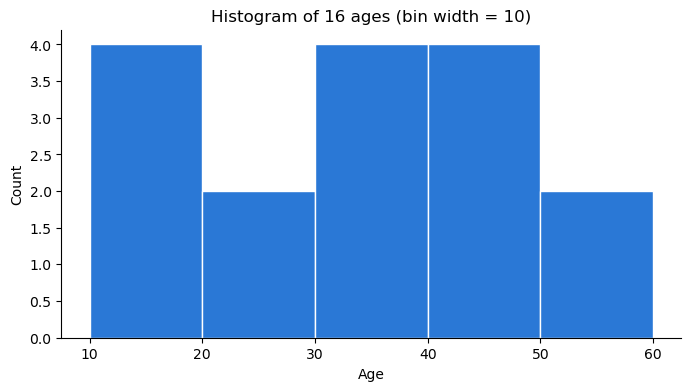

In [15]:
fig, ax = plt.subplots()
ax.hist(ages, bins=bin_edges, color=BLUE, edgecolor="white")
ax.set_title("Histogram of 16 ages (bin width = 10)")
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.show()

The chart matches the manual table: 4, 2, 4, 4, 2.

Now the real data. Let's look at the bill amounts.

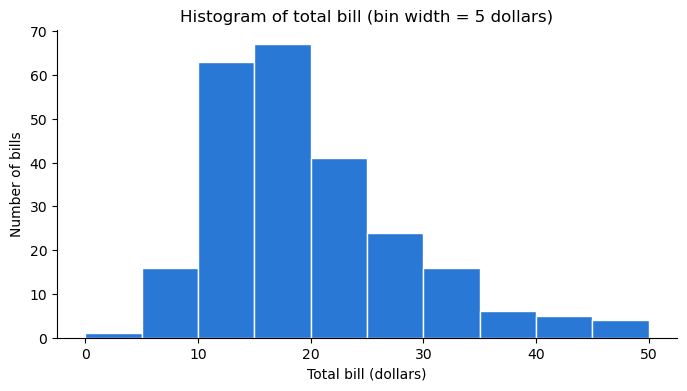

In [16]:
fig, ax = plt.subplots()
ax.hist(tips["total_bill"], bins=range(0, 55, 5), color=BLUE, edgecolor="white")
ax.set_title("Histogram of total bill (bin width = 5 dollars)")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Number of bills")
plt.show()

Most bills are between 10 and 25 dollars. There is a long tail to the right: a few big bills up to about 50 dollars. We call this shape **right-skewed**. We will come back to skewness in the next notebook.

### The number of bins changes the picture

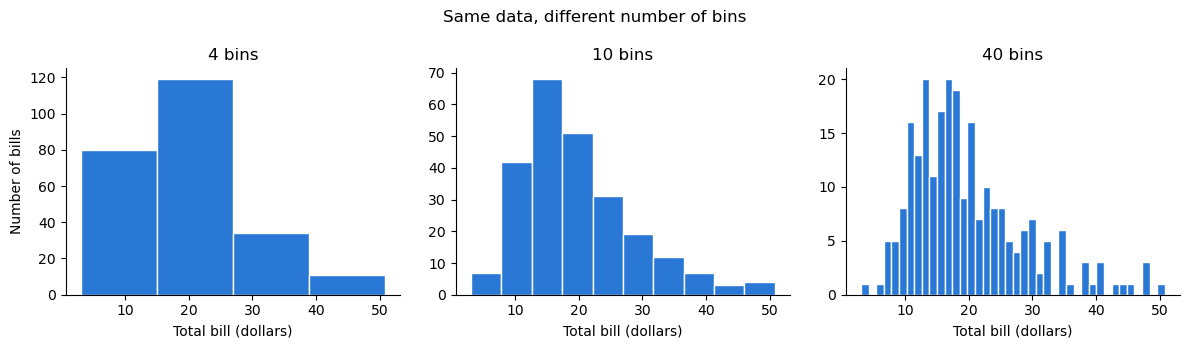

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=False)
for ax, bins in zip(axes, [4, 10, 40]):
    ax.hist(tips["total_bill"], bins=bins, color=BLUE, edgecolor="white")
    ax.set_title(f"{bins} bins")
    ax.set_xlabel("Total bill (dollars)")
axes[0].set_ylabel("Number of bills")
fig.suptitle("Same data, different number of bins")
plt.tight_layout()
plt.show()

With 4 bins we lose the detail, with 40 bins the chart becomes noisy. Something in the middle (around 10 to 20 bins) usually tells the story best.

---
## 8. From histogram to PDF (density curve)

> **Theory.** If we smooth a histogram into a curve, we get an estimate of the **probability density function (PDF)**. The tool that does the smoothing is called a **kernel density estimator (KDE)**.

The idea of KDE in simple words: put a small "bump" (a little bell curve) on top of every data point, then add all the bumps together. Where many points are close, the bumps pile up and the curve is high.

Read more: [Kernel density estimation (Wikipedia)](https://en.wikipedia.org/wiki/Kernel_density_estimation)

**Why do we need it?** A smooth curve shows the shape of the data (one peak or two, symmetric or skewed) without depending so much on the choice of bins.

**Small example:** three points only, so we can see the bumps.

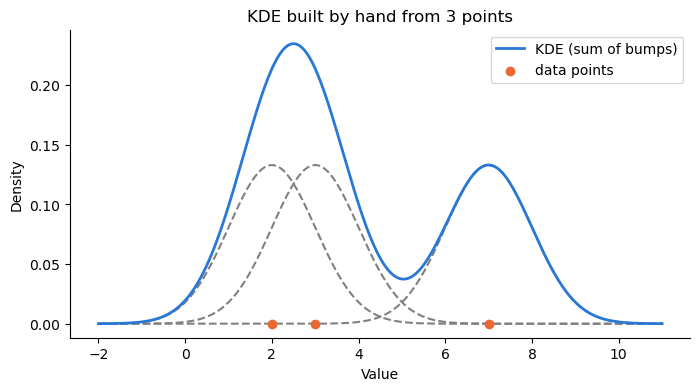

In [18]:
points = np.array([2.0, 3.0, 7.0])
x = np.linspace(-2, 11, 300)
bandwidth = 1.0

fig, ax = plt.subplots()
total = np.zeros_like(x)
for p in points:
    bump = np.exp(-0.5 * ((x - p) / bandwidth) ** 2) / (bandwidth * np.sqrt(2 * np.pi))
    bump = bump / len(points)
    total = total + bump
    ax.plot(x, bump, color="grey", linestyle="--")

ax.plot(x, total, color=BLUE, linewidth=2, label="KDE (sum of bumps)")
ax.scatter(points, np.zeros_like(points), color=ORANGE, zorder=3, label="data points")
ax.set_title("KDE built by hand from 3 points")
ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.legend()
plt.show()

The dashed grey lines are the bumps, one per point. The blue line is their sum. Points 2 and 3 are close, so their bumps join into one higher hill.

Now the same thing on the real bills, using seaborn:

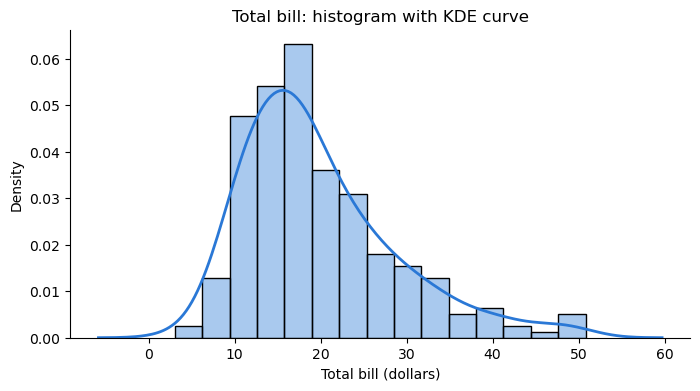

In [19]:
fig, ax = plt.subplots()
sns.histplot(tips["total_bill"], bins=15, stat="density", color=BLUE, alpha=0.4, ax=ax)
# docs: https://seaborn.pydata.org/generated/seaborn.kdeplot.html
sns.kdeplot(tips["total_bill"], color=BLUE, linewidth=2, ax=ax)
ax.set_title("Total bill: histogram with KDE curve")
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Density")
plt.show()

The curve follows the bars and makes the right skew easy to see: one peak around 15 dollars and a long tail to the right.

Note that the y-axis is now **density**, not count. The total area under a density curve is 1, which is why the PDF can later be used to read probabilities.

---
## Summary

| Idea | One-line meaning |
|---|---|
| Statistics | Collecting, organising and analysing data to make decisions |
| Descriptive vs inferential | Describe the data you have vs draw conclusions about a bigger group |
| Population (N) vs sample (n) | Everyone vs the part we observed |
| Sampling techniques | Random, stratified, systematic, convenience. Convenience is often biased |
| Variables | Quantitative (discrete / continuous) or qualitative (categorical) |
| Measurement scales | Nominal, ordinal, interval, ratio |
| Bar chart vs histogram | Categories vs continuous values |
| PDF / KDE | A smooth version of the histogram, area under it = 1 |

## What's next

In **02 · Central Tendency and Spread** we describe a variable with numbers: mean, median, mode, variance, standard deviation, percentiles, the five-number summary and box plots, and we use them to find outliers.

## References and further reading

- [OpenIntro Statistics](https://www.openintro.org/book/os/) (free textbook), chapter 1 (data basics) and chapter 2 (summarising data)
- [Sampling (statistics), Wikipedia](https://en.wikipedia.org/wiki/Sampling_(statistics))
- [Level of measurement, Wikipedia](https://en.wikipedia.org/wiki/Level_of_measurement)
- [pandas `value_counts`](https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html) · [matplotlib `hist`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) · [seaborn `kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html)